<a href="https://colab.research.google.com/github/KhadijaTheAnalyst/dlh-modern_ai/blob/main/Telco_Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [6]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [75]:
shape = df.shape

In [76]:
data_types = df.dtypes

In [77]:
head = df.head()

In [78]:
missing_count = df.isnull().sum()

In [79]:
duplicates = df.duplicated().sum()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [80]:
print("Shape:", shape)
print("\nData Types:")
print(data_types)
print("\nHead:")
print(head)
print("\nMissing Values:")
print(missing_count)
print("\nDuplicate Rows:", duplicates)

Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Head:
   customerID  gender  SeniorCitizen Partner Dependents  tenure  ...  \
0  7590-VHVEG  Female              0     Yes         No       1  ...   
1  5575-GNVDE    Male              0      No         No      34  ...   
2  3668-QPYBK    Male              0      No         No       2  ...   
3  7795-CFOCW    Male              0      No         No      45  ...   


In [81]:
import numpy as np
import matplotlib.pyplot as plt

In [82]:
def plot_missingness(df):
    plt.figure(figsize=(12,8))
    x,y = np.where(df.isnull())
    plt.scatter(x,y,marker="|", color = 'C0')
    plt.yticks(range(len(df.columns)), df.columns)
    plt.xlabel('Row Index')
    plt.ylabel('Column')
    plt.title('Missingness Plot')
    plt.show()

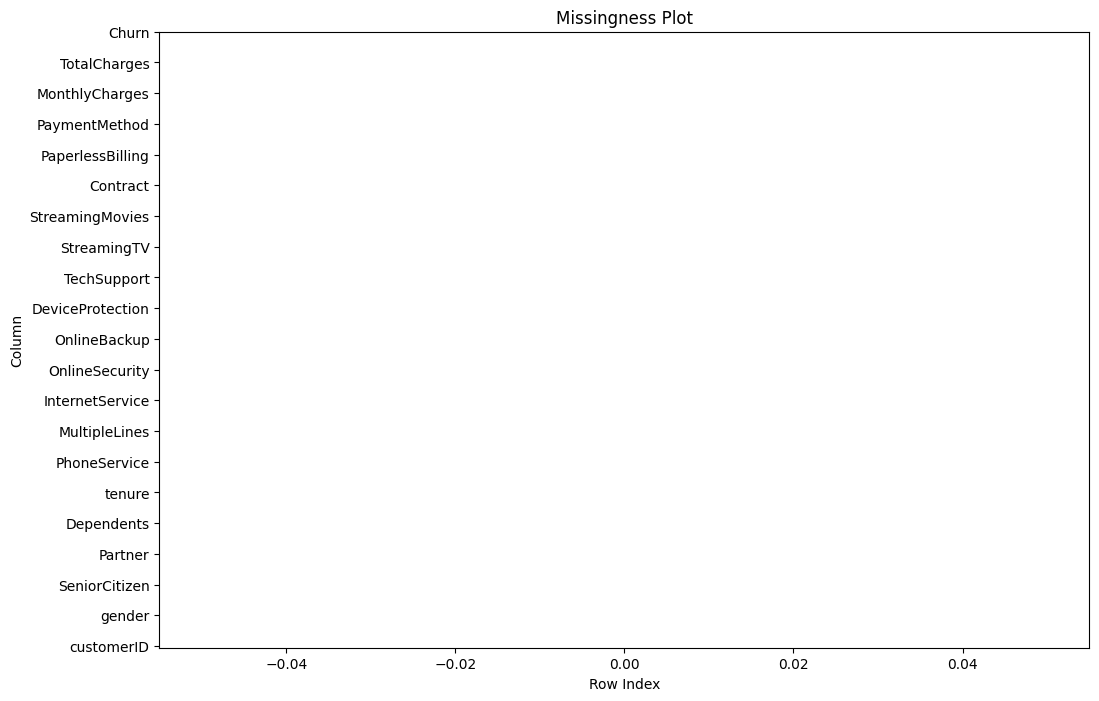

In [83]:
plot_missingness(df)

In [84]:
df = pd.read_csv('Telco-Customer-Churn.csv')
non_numeric = [
    val for val in df['TotalCharges'].unique()
    if not str(val).replace('.', '').replace('-', '').isdigit()
]
print("Non-numeric values: ", non_numeric)

Non-numeric values:  [' ']


  customerID  gender Partner  tenure  TotalCharges Churn
0          A    Male     Yes     1.0         29.85    No
1          B  Female      No    24.0       2138.40   Yes
2          C     NaN      No     5.0           NaN   NaN
3          A    Male     NaN     1.0         29.85    No
4          D  Female     Yes    36.0       3803.40  None
5          E    Male    None     NaN          0.00    No


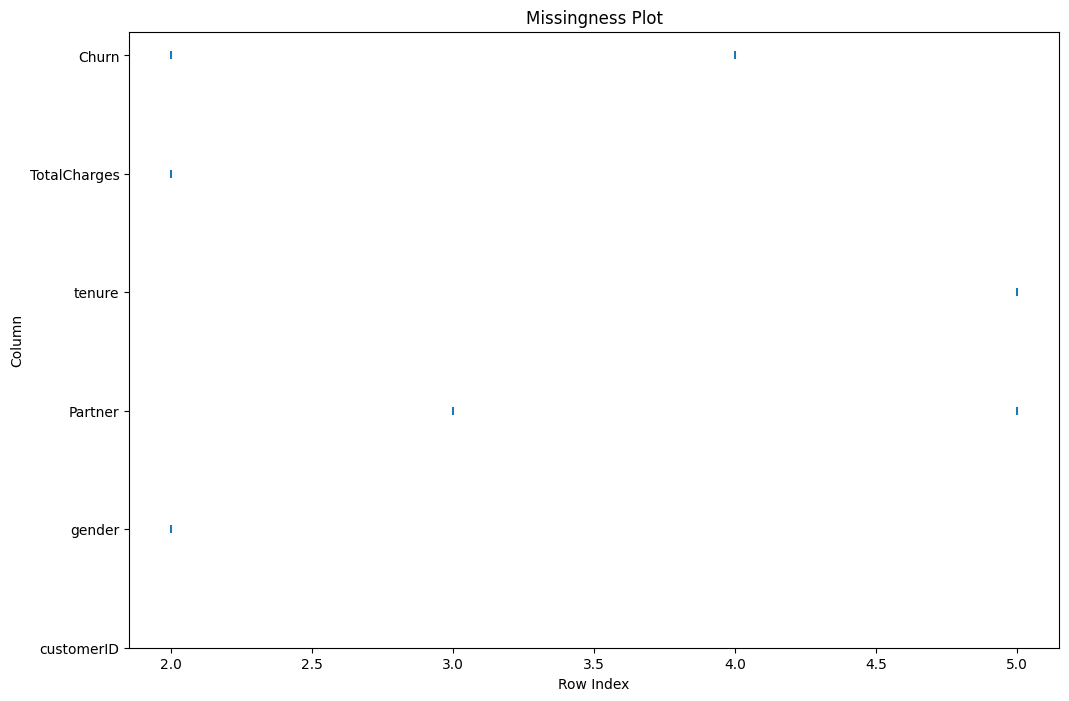

In [85]:
data = {
    'customerID': ['A', 'B', 'C', 'A', 'D', 'E'],
    'gender': ['Male', 'Female', np.nan, 'Male', 'Female', 'Male'],
    'Partner': ['Yes', 'No', 'No', np.nan, 'Yes', None],
    'tenure': [1, 24, 5, 1, 36, np.nan],
    'TotalCharges': [29.85, 2138.40, np.nan, 29.85, 3803.40, 0],
    'Churn': ['No', 'Yes', np.nan, 'No', None, 'No']
}
test_df = pd.DataFrame(data)
print(test_df)
plot_missingness(test_df)

In [86]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges']

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [64]:
df['SeniorCitizen']=df['SeniorCitizen'].map({1:'Yes' , 0:'No'})
df['SeniorCitizen']

,SeniorCitizen
0,No
1,No
2,No
3,No
4,No
...,...
7038,No
7039,No
7040,No
7041,Yes


In [5]:
def convert_columns(df):
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['SeniorCitizen']=df['SeniorCitizen'].map({1:'Yes' , 0:'No'})
    return df

SeniorCitizen column type after conversion: int64
Unique values in the 'SeniorCitizen' column: [0 1]

TotalCharges column type after conversion: float64
Missing values in TotalCharges after conversion: 11


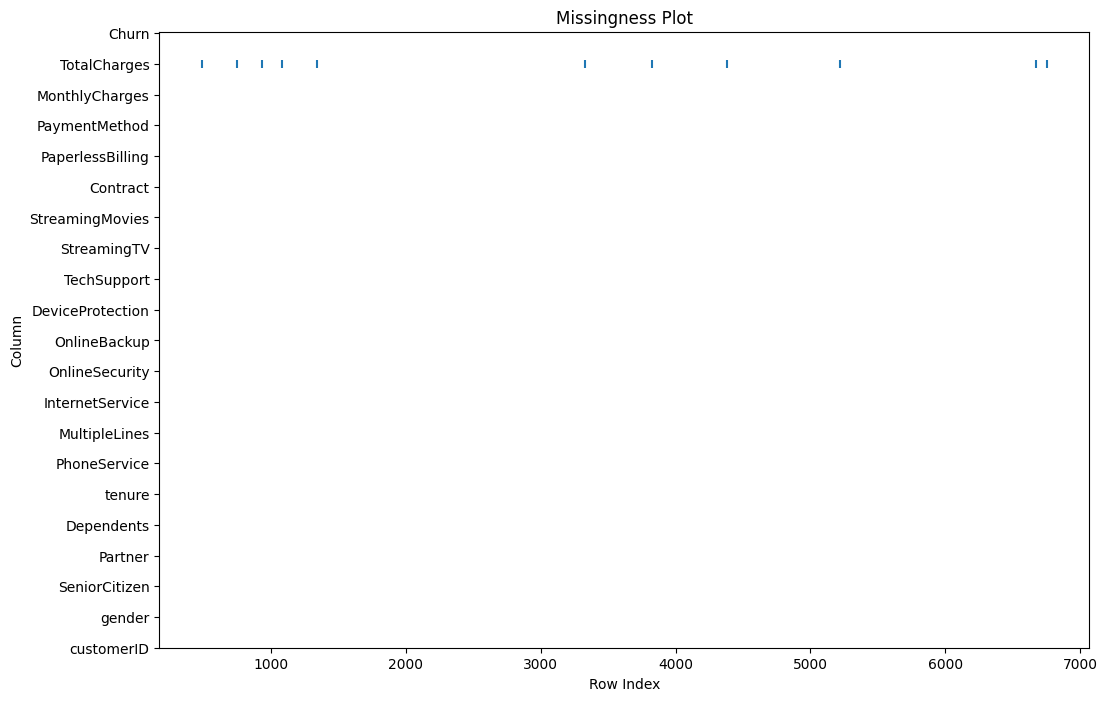

In [87]:
print("SeniorCitizen column type after conversion:", df['SeniorCitizen'].dtype)
print("Unique values in the 'SeniorCitizen' column:", df['SeniorCitizen'].unique())
print("\nTotalCharges column type after conversion:", df['TotalCharges'].dtype)
print("Missing values in TotalCharges after conversion:", df['TotalCharges'].isna().sum())
plot_missingness(df)

In [88]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df = convert_columns(df)
pd.set_option('display.max_columns', 12)
print(df[df['TotalCharges'].isna()])

      customerID  gender SeniorCitizen Partner Dependents  tenure  ...  \
488   4472-LVYGI  Female            No     Yes        Yes       0  ...   
753   3115-CZMZD    Male            No      No        Yes       0  ...   
936   5709-LVOEQ  Female            No     Yes        Yes       0  ...   
1082  4367-NUYAO    Male            No     Yes        Yes       0  ...   
1340  1371-DWPAZ  Female            No     Yes        Yes       0  ...   
3331  7644-OMVMY    Male            No     Yes        Yes       0  ...   
3826  3213-VVOLG    Male            No     Yes        Yes       0  ...   
4380  2520-SGTTA  Female            No     Yes        Yes       0  ...   
5218  2923-ARZLG    Male            No     Yes        Yes       0  ...   
6670  4075-WKNIU  Female            No     Yes        Yes       0  ...   
6754  2775-SEFEE    Male            No      No        Yes       0  ...   

      Contract PaperlessBilling              PaymentMethod MonthlyCharges  \
488   Two year              Yes  B

In [1]:
def clean_total_charges(df, method='drop'):
    if method == 'drop':
        df = df.dropna(subset=['TotalCharges'])
    elif method == 'median':
        median_value = df['TotalCharges'].median()
        df['TotalCharges'].fillna(median_value, inplace=True)
    elif method == 'impute':
        df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'], inplace=True)
    return df

In [6]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('Telco-Customer-Churn.csv')
df = convert_columns(df)
df1 = clean_total_charges(df)
df2 = clean_total_charges(df, method='impute')
df3 = clean_total_charges(df, method='median')
nan_indices = df[df['TotalCharges'].isna()].index
print("Missing after drop:", df1['TotalCharges'].isna().sum())
print("Missing after impute:", df2.loc[nan_indices, 'TotalCharges'])
print("Missing after median:", df3.loc[nan_indices, 'TotalCharges'])

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv
Missing after drop: 0
Missing after impute: Series([], Name: TotalCharges, dtype: float64)
Missing after median: Series([], Name: TotalCharges, dtype: float64)


/tmp/ipykernel_937/645513994.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'], inplace=True)
/tmp/ipykernel_937/645513994.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [7]:
def remove_duplicates(df):
    df = df.drop_duplicates()
    return df


In [8]:
remove_duplicates(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [9]:
def drop_customerID(df):
    df = df.drop('customerID', axis=1)
    return df

In [12]:
drop_customerID(df)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [2]:
df.to_csv('precleaned-Telco-Customer-Churn.csv', index=False)

NameError: name 'df' is not defined

In [3]:
import pandas as pd

In [4]:
from google.colab import files

uploaded = files.upload()

Saving precleaned-Telco-Customer-Churn.csv to precleaned-Telco-Customer-Churn.csv


In [5]:
df = pd.read_csv("precleaned-Telco-Customer-Churn.csv")

In [31]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
print(df['Churn'].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [24]:
import matplotlib.pyplot as plt


def plot_churn_distribution(df):
    x = df['Churn'].value_counts()
    color_mapping = {'No':'skyblue', 'Yes':'salmon'}
    colors = [color_mapping[val] for val in x.index]
    x.plot(kind='bar', color = colors)
    plt.xlabel('Churn')
    plt.ylabel('Count')
    plt.title('Churn Distribution')
    plt.show()

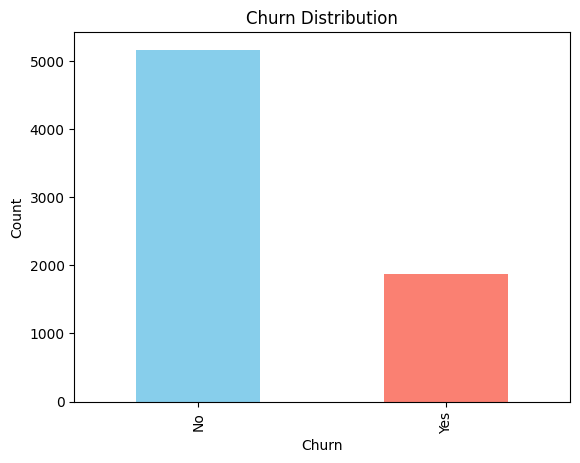

In [25]:
plot_churn_distribution(df)

In [38]:
def plot_categorical_distributions(df, columns_to_plot=None):
    """
    """
    if columns_to_plot is None:
        col_type = df.select_dtypes(include = 'object').columns
        columns_to_plot = [ c for c in col_type if c != 'Churn']
    else:
        pass
    n_cols = 3
    n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

    for i, column in enumerate(columns_to_plot):
        counts = df[column].value_counts()
        row = i // n_cols
        col = i % n_cols
        ax = axes[row][col]
        ax.bar(counts.index, counts.values)
        ax.set_title(column)
        ax.tick_params(axis='x', rotation=45)

    for i in range(len(columns_to_plot), n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig("Task_7.png")
    plt.show()

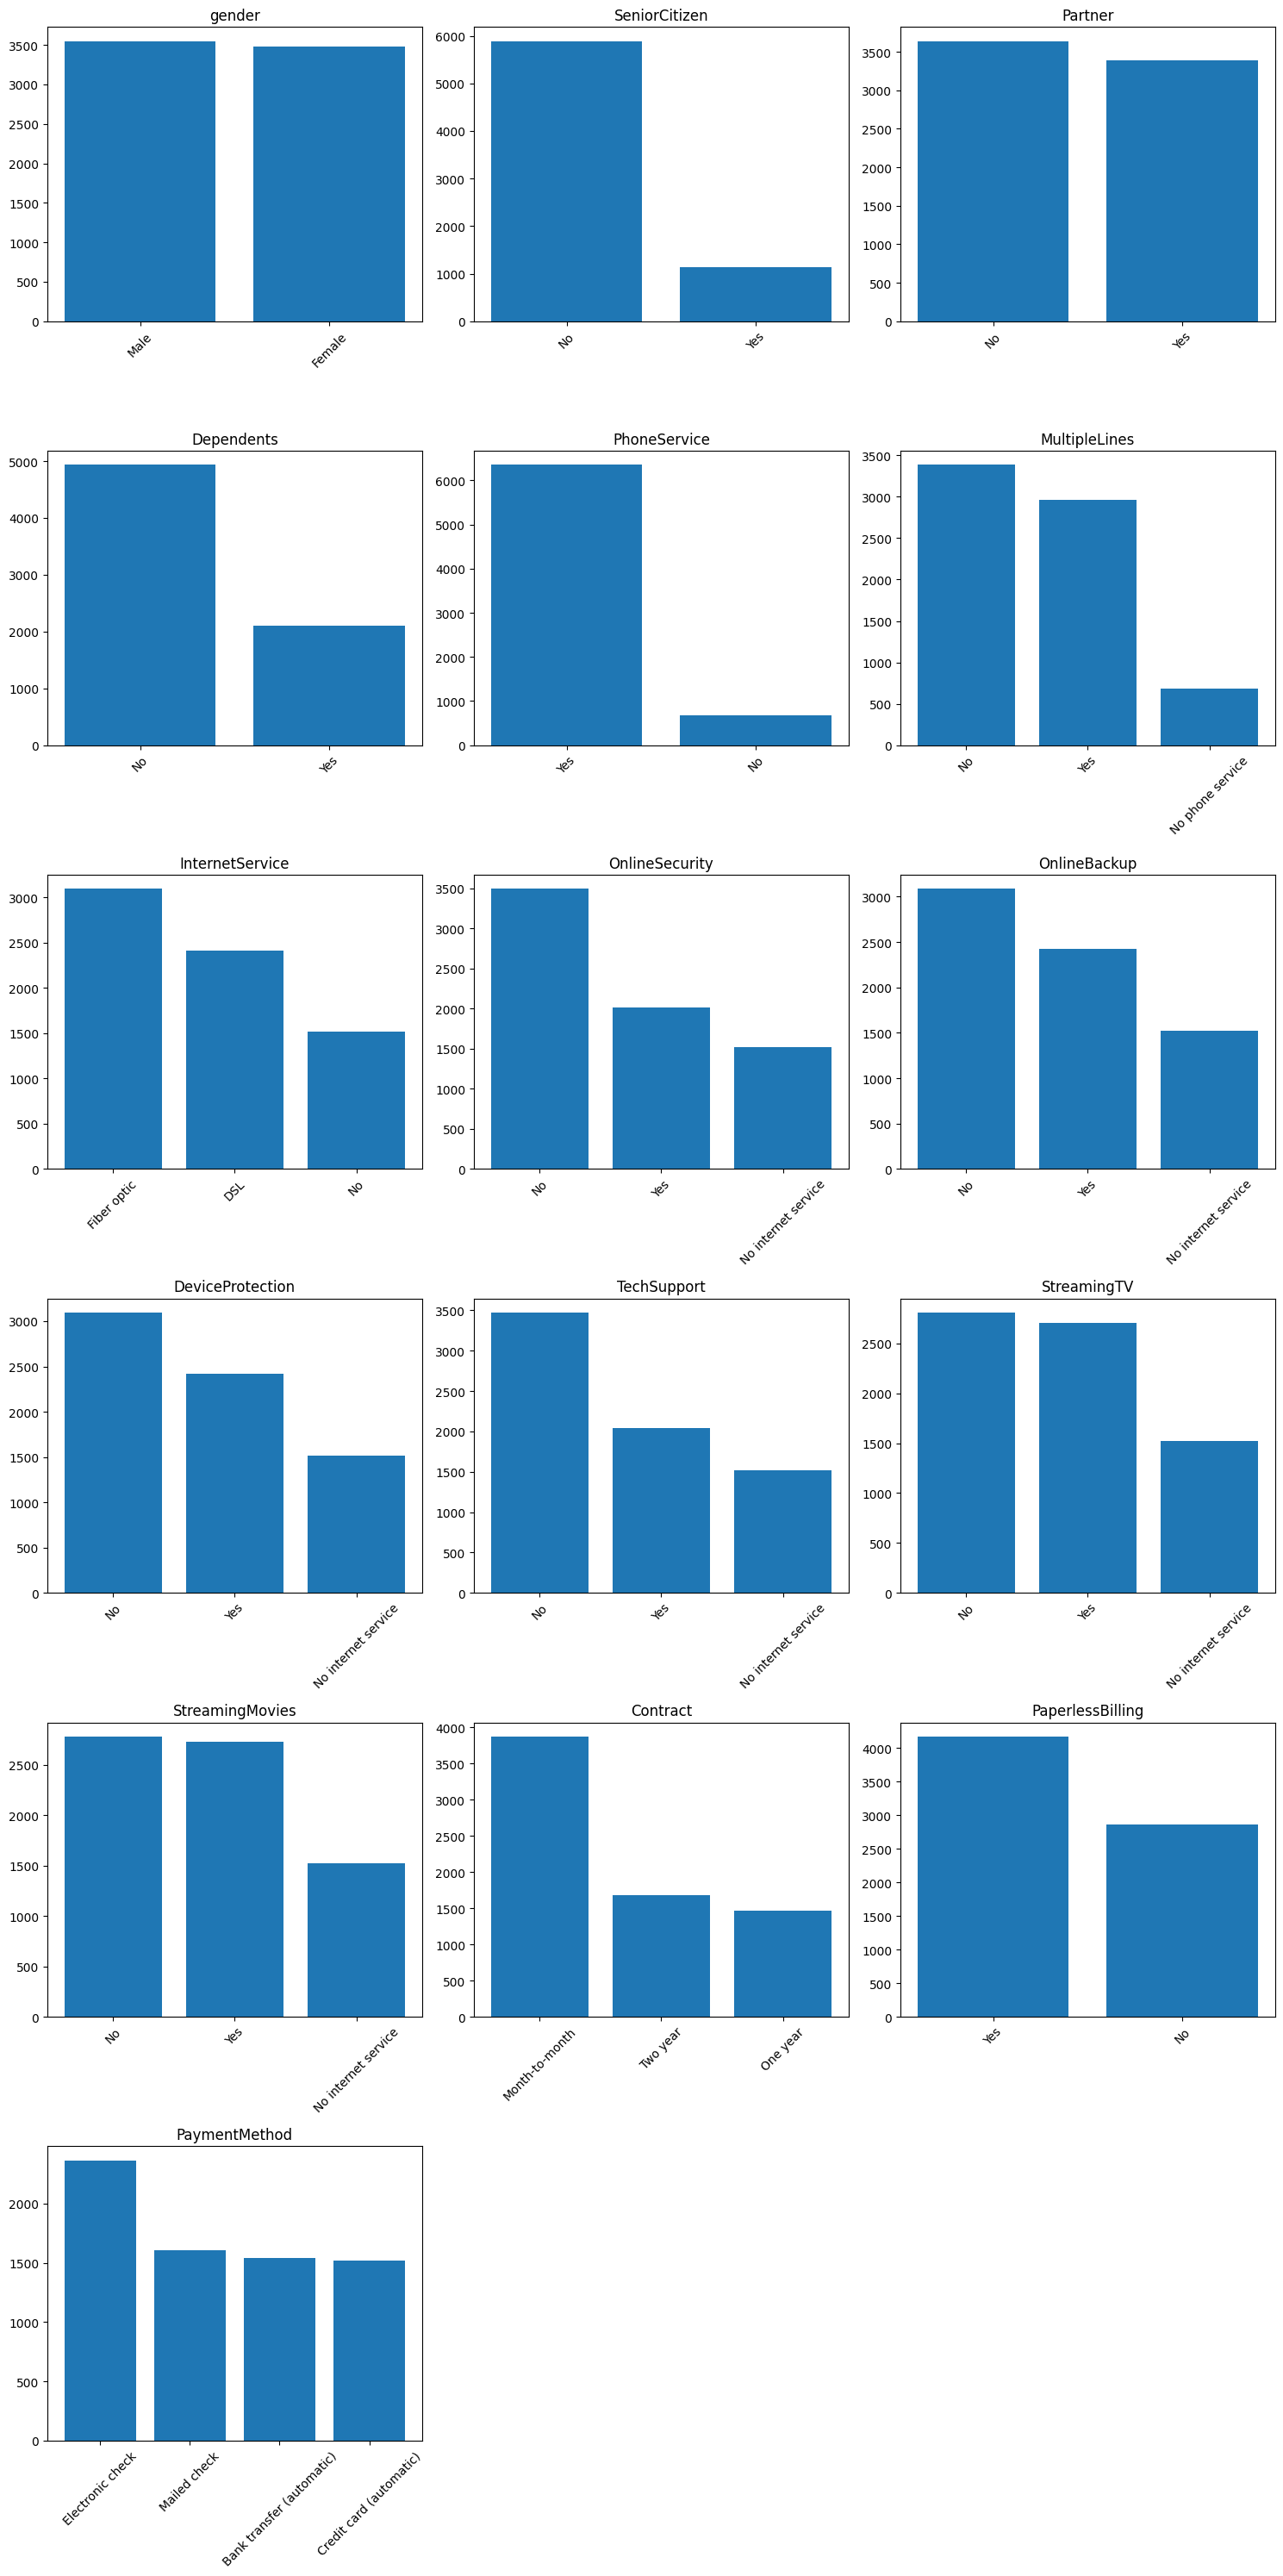

In [39]:
plot_categorical_distributions(df)

In [32]:
col_type = df.select_dtypes(include = 'object').columns

In [33]:
cols = [ c for c in col_type if c != 'Churn']
print(cols)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [35]:
# for understanding the work flow
def plot_categorical_distributions(df, columns_to_plot=None):
    """
    """
    if columns_to_plot is None:
        col_type = df.select_dtypes(include = 'object').columns
        columns_to_plot = [ c for c in col_type if c != 'Churn']
    else:
        pass
    n_cols = 3
    n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    for i, column in enumerate(columns_to_plot):
        print(f"--- iteration i={i} ---")
        print("column:", column)

        counts = df[column].value_counts()
        print("counts:\n", counts)

        row = i // n_cols
        col = i % n_cols
        print(f"row={row}, col={col}")

        ax = axes[row][col]
        ax.bar(counts.index, counts.values)
        ax.set_title(column)
        ax.tick_params(axis='x', rotation=45)

--- iteration i=0 ---
column: gender
counts:
 gender
Male      3549
Female    3483
Name: count, dtype: int64
row=0, col=0
--- iteration i=1 ---
column: SeniorCitizen
counts:
 SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64
row=0, col=1
--- iteration i=2 ---
column: Partner
counts:
 Partner
No     3639
Yes    3393
Name: count, dtype: int64
row=0, col=2
--- iteration i=3 ---
column: Dependents
counts:
 Dependents
No     4933
Yes    2099
Name: count, dtype: int64
row=1, col=0
--- iteration i=4 ---
column: PhoneService
counts:
 PhoneService
Yes    6352
No      680
Name: count, dtype: int64
row=1, col=1
--- iteration i=5 ---
column: MultipleLines
counts:
 MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
row=1, col=2
--- iteration i=6 ---
column: InternetService
counts:
 InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
row=2, col=0
--- iteration i=7 ---
colum

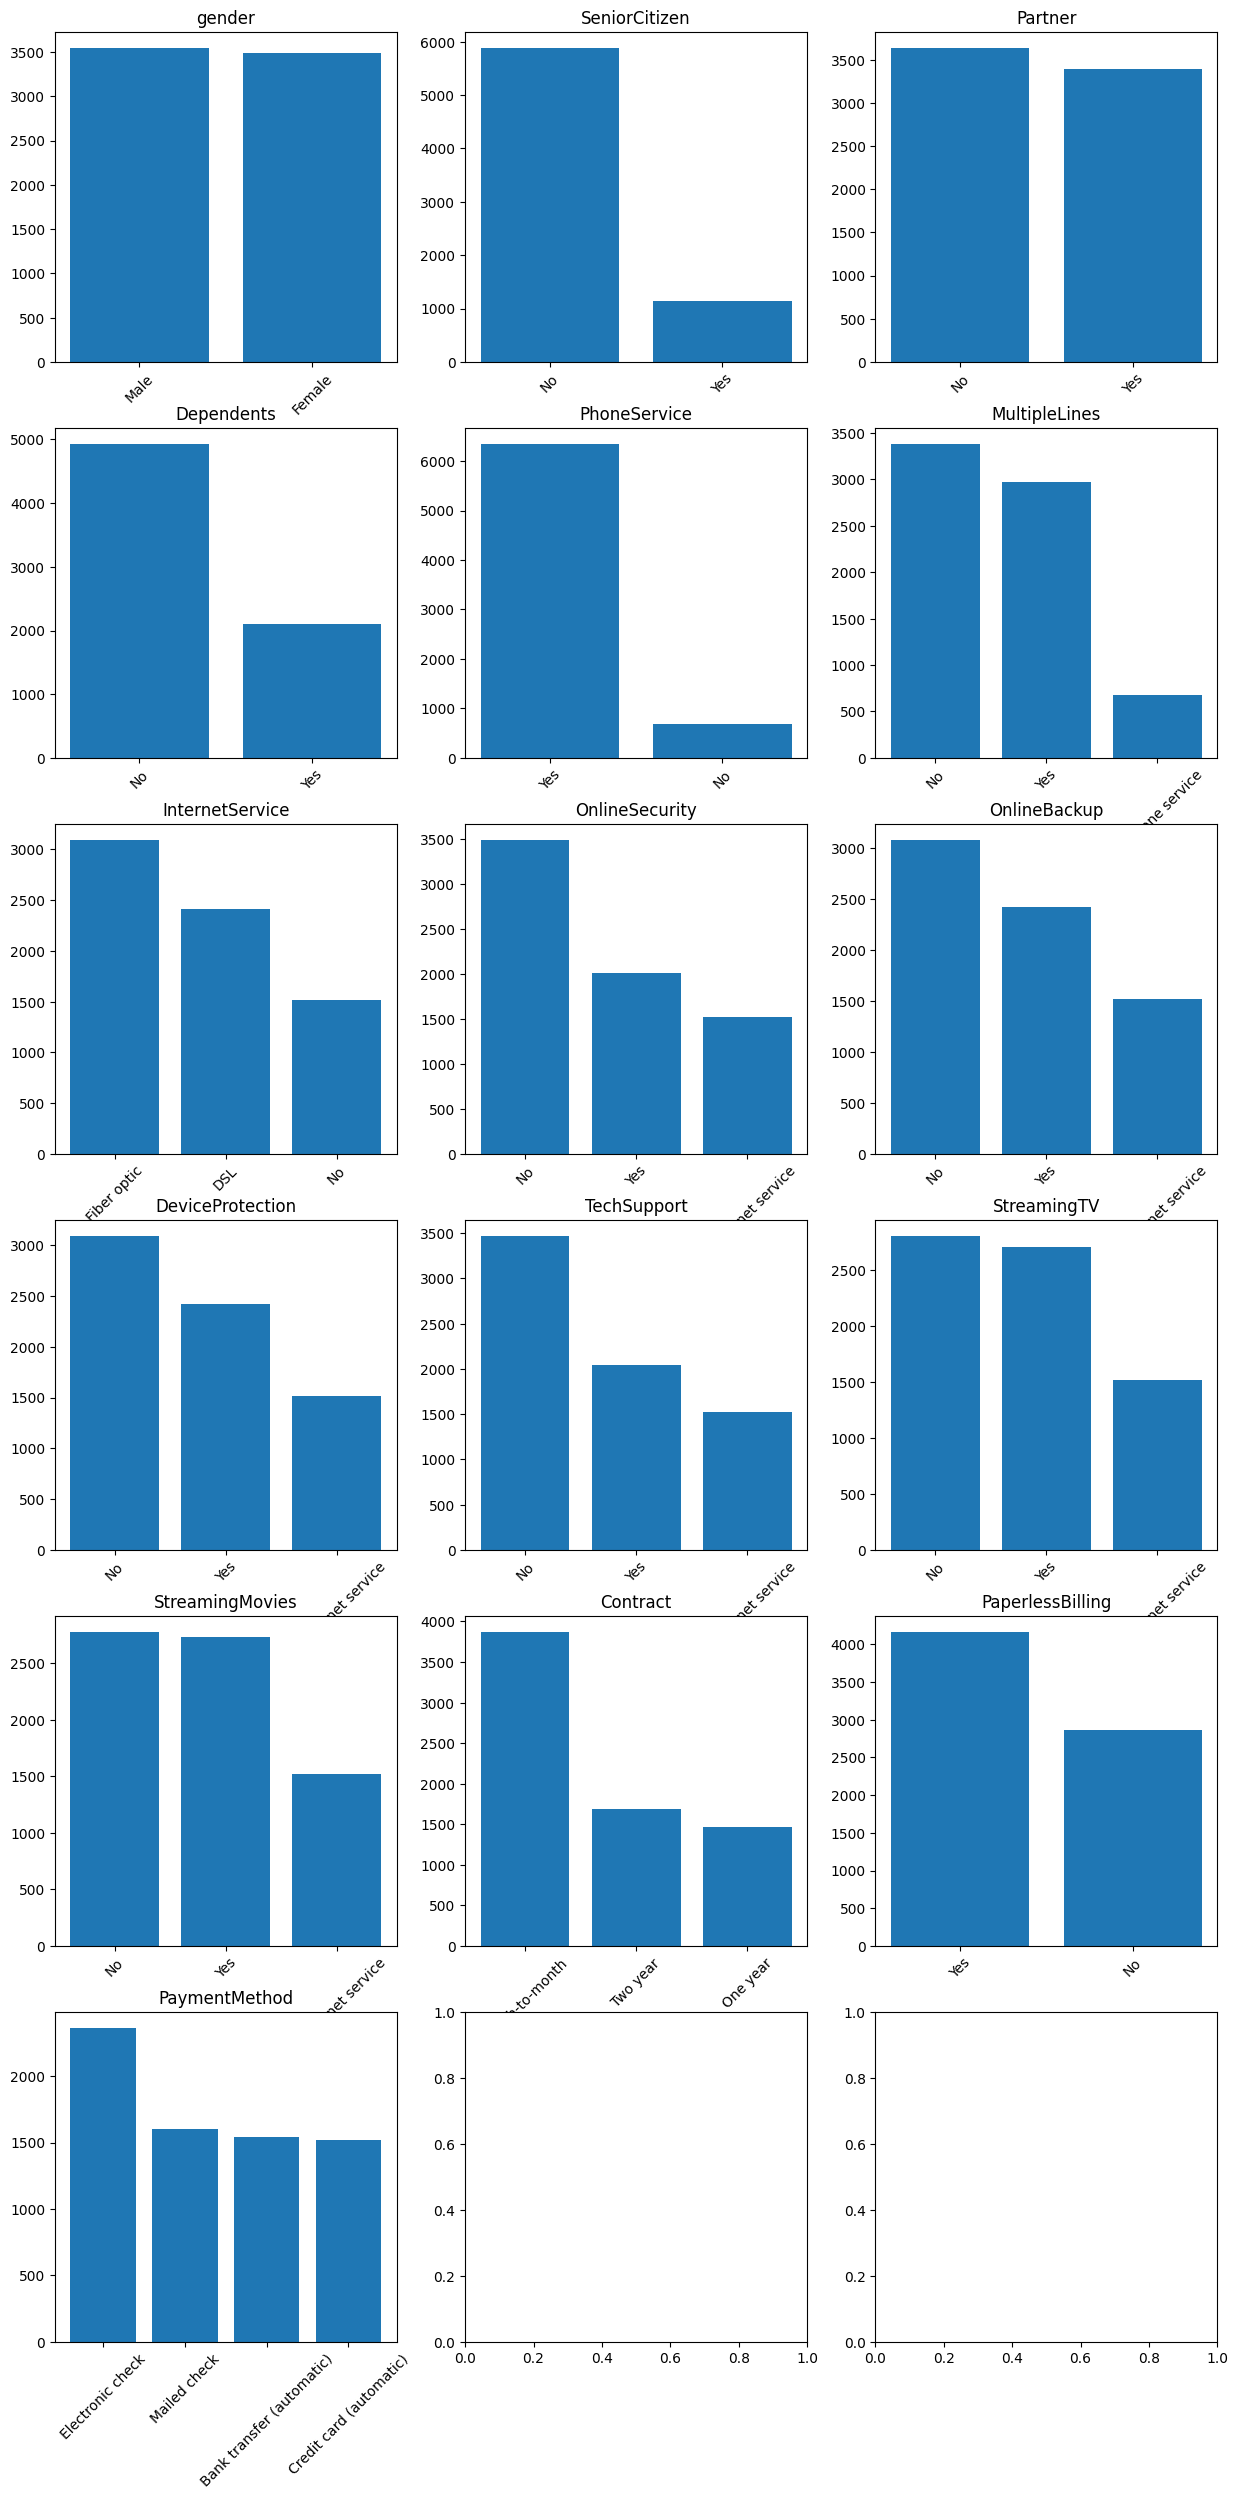

In [30]:
plot_categorical_distributions(df)

In [48]:
import seaborn as sns

def plot_continuous_distributions(df, columns_to_plot=None):
    """
    """
    if columns_to_plot is None:
        columns_to_plot = df.select_dtypes(include = ['int64','float64']).columns
    else:
        pass

    n_rows = len(columns_to_plot)
    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3*n_rows))

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for i, column in enumerate(columns_to_plot):
        row = i
        hist_ax = axes[row,0]
        box_ax = axes[row,1]
        hist_ax.hist(df[column], bins =30 , density = True, alpha = 0.7, edgecolor = 'black')
        sns.kdeplot(df[column], ax=hist_ax, color='red')
        hist_ax.set_title(f'{column} Histogram + KDE')

        box_ax.boxplot(df[column], vert = False)
        box_ax.set_title(f'{column} Boxplot')

    plt.tight_layout()
    plt.savefig("Task_8.png")
    plt.show()

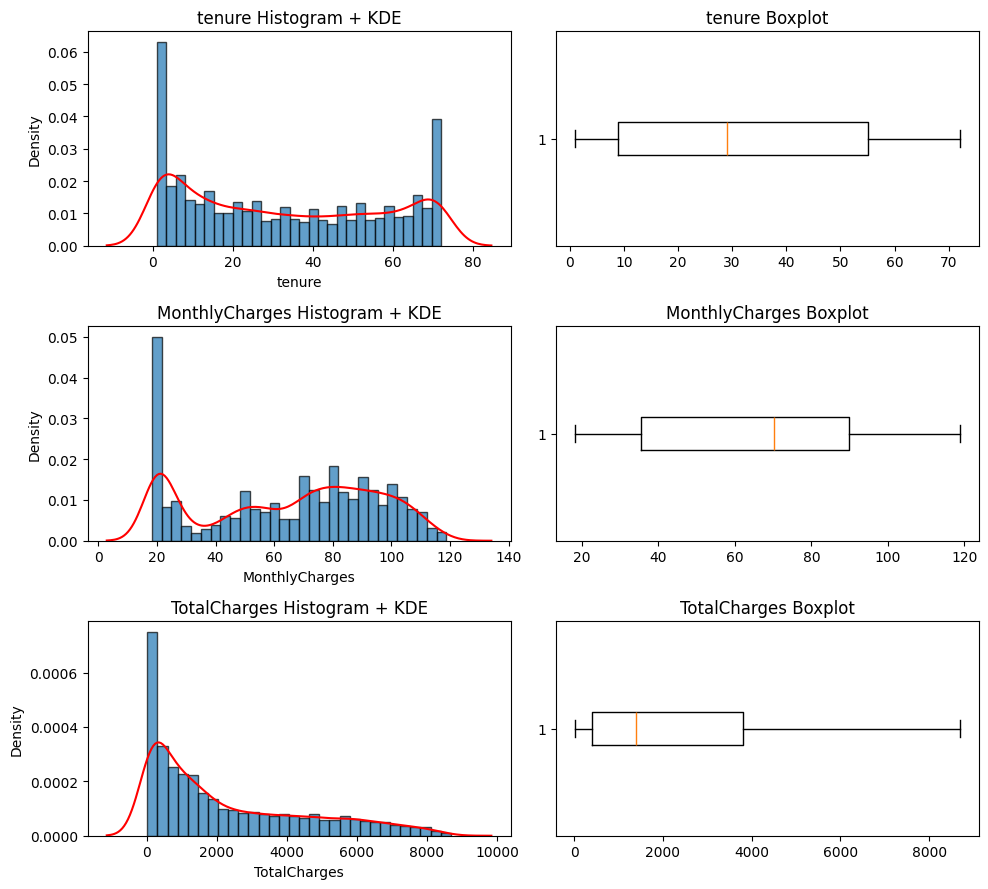

In [49]:
plot_continuous_distributions(df)

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_correlation_heatmap(df):
    """
    """
    plt.figure(figsize=(6, 5))

    df_corr = df.select_dtypes(include=['int64', 'float64'])

    sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation Heatmap')
    plt.show()

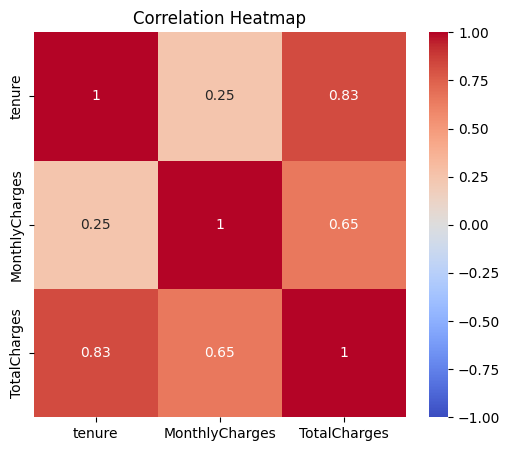

In [55]:
plot_correlation_heatmap(df)

In [27]:
def plot_categorical_vs_churn(df, col):
  plt.figure(figsize=(12,8))

  Churn_numeric = df['Churn'].map({'No':0, 'Yes':1})
  Churn_rate = Churn_numeric.groupby(df[col]).mean()

  plt.bar(Churn_rate.index, Churn_rate.values)

  plt.title(f'Churn Rate by {col}')
  plt.ylabel('Churn Rate')
  plt.xlabel(col)
  plt.xticks(rotation=45)
  plt.show()


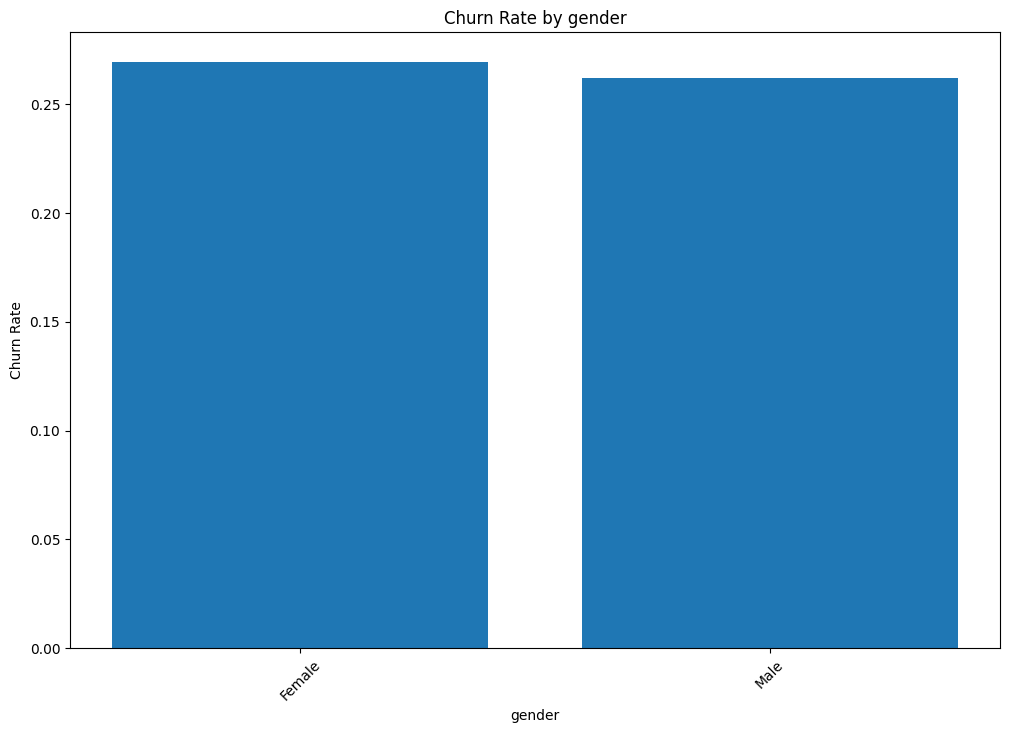

In [62]:
plot_categorical_vs_churn(df, 'gender')

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_numeric_vs_churn(df, col):

    plt.figure(figsize=(12,8))

    churned = df[df['Churn'] == 'Yes'][col]
    not_churned = df[df['Churn'] == 'No'][col]


    plt.hist([not_churned, churned], bins=30, label =['No', 'Yes'])

    plt.title(f'{col} Distribution by Churn')
    plt.xlabel(col)
    plt.legend(title = 'Churn')
    plt.show()

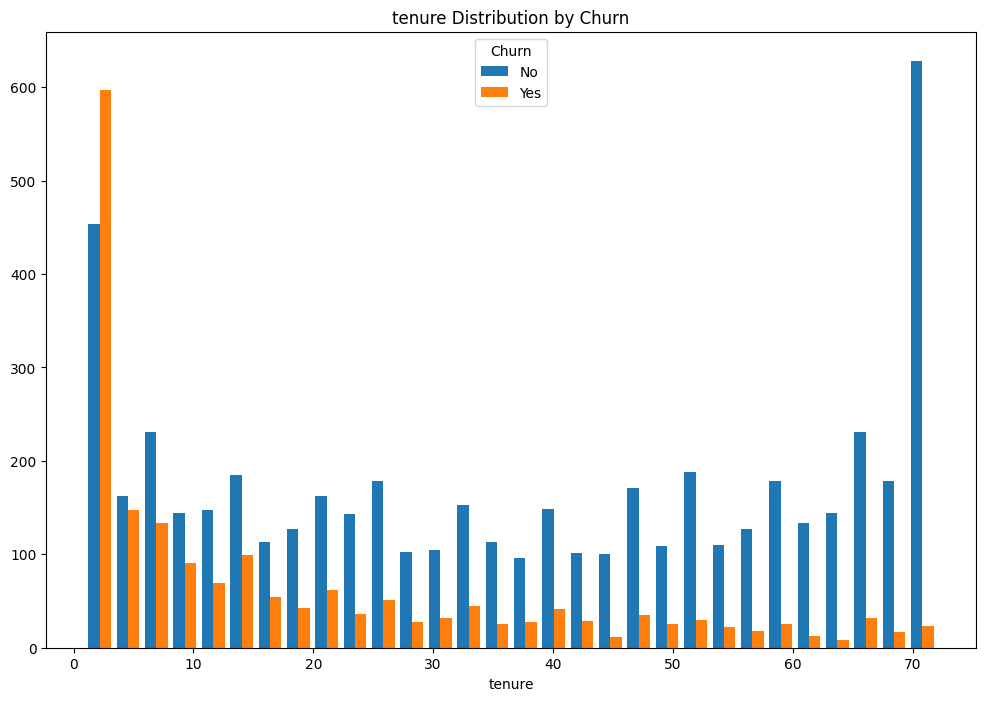

In [24]:
plot_numeric_vs_churn(df, 'tenure')

In [6]:
df[df['Churn'] == 'Yes']['tenure']

,tenure
2,2
4,2
5,8
8,28
13,49
...,...
7010,12
7015,9
7021,1
7023,67


In [7]:
df[df['Churn'] == 'No']['tenure']

,tenure
0,1
1,34
3,45
6,22
7,10
...,...
7026,72
7027,24
7028,72
7029,11


In [6]:
import pandas as pd

from scipy import stats


def chi_square_tests(df):
    """
    """

    col_type = df.select_dtypes(include='object').columns
    columns_to_plot = [c for c in col_type if c != 'Churn']

    result = {}
    for column in columns_to_plot:
        contingency_table = pd.crosstab(df[column], df['Churn'])
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
        result[column] = float(p)

    return result

In [7]:
chi_square_tests(df)

{'gender': 0.4904884707065509,
 'SeniorCitizen': 2.4792557203954705e-36,
 'Partner': 3.97379757451591e-36,
 'Dependents': 2.0196592017051303e-42,
 'PhoneService': 0.34992398942431924,
 'MultipleLines': 0.0035679273999811405,
 'InternetService': 5.831198962237274e-159,
 'OnlineSecurity': 1.4006867477839222e-184,
 'OnlineBackup': 7.776099238804965e-131,
 'DeviceProtection': 1.9593887862403176e-121,
 'TechSupport': 7.407807748843711e-180,
 'StreamingTV': 1.324641113169159e-81,
 'StreamingMovies': 5.353560421401324e-82,
 'Contract': 7.326182186265472e-257,
 'PaperlessBilling': 8.236203353962564e-58,
 'PaymentMethod': 1.4263098511063342e-139}

In [29]:
pd.crosstab(df['Partner'], df['Churn'])


Churn,No,Yes
Partner,,
No,2439,1200
Yes,2724,669


In [9]:
def ttest_numeric(df):
  """
  """
  numeric_col = df.select_dtypes(include=['int64','float64']).columns


  result = {}
  for column in numeric_col:
    churned = df[df['Churn'] == 'Yes'][column]
    not_churned = df[df['Churn'] == 'No'][column]
    t_stat, p = stats.ttest_ind(not_churned, churned, equal_var= False)
    result[column] = float(p)

  return result




In [10]:
ttest_numeric(df)

{'tenure': 2.3470747188949526e-234,
 'MonthlyCharges': 2.6573571445160277e-72,
 'TotalCharges': 1.1524944112838114e-75}

In [11]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [51]:
def create_features(df):
  service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
  mapped_services = df[service_cols].map(lambda x: 1 if x == 'Yes' else 0)
  internet_mapped = df['InternetService'].map({'DSL': 1, 'Fiber optic': 1, 'No': 0})
  mapped_services['InternetService'] = internet_mapped
  df['NumServices'] = mapped_services.sum(axis=1)
  df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12,24,48,60,float('inf')], labels = ['0-12', '13-24', '25-48', '49-60','60+'])
  cols_to_drop = service_cols + ['InternetService', 'tenure']
  df = df.drop(cols_to_drop, axis = 1)
  return df


In [31]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,NumServices,TenureGroup
0,Female,0.0,1.0,0.0,1,No,No phone service,DSL,No,Yes,...,29.85,29.85,No,False,False,False,True,False,2,0-12
1,Male,0.0,0.0,0.0,34,Yes,No,DSL,Yes,No,...,56.95,1889.50,No,True,False,False,False,True,3,25-48
2,Male,0.0,0.0,0.0,2,Yes,No,DSL,Yes,Yes,...,53.85,108.15,Yes,False,False,False,False,True,3,0-12
3,Male,0.0,0.0,0.0,45,No,No phone service,DSL,Yes,No,...,42.30,1840.75,No,True,False,False,False,False,4,25-48
4,Female,0.0,0.0,0.0,2,Yes,No,Fiber optic,No,No,...,70.70,151.65,Yes,False,False,False,True,False,1,0-12


In [52]:
create_features(df)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NumServices,TenureGroup
0,Female,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,0-12
1,Male,No,No,No,Yes,One year,No,Mailed check,56.95,1889.50,No,3,25-48
2,Male,No,No,No,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3,0-12
3,Male,No,No,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4,25-48
4,Female,No,No,No,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Male,No,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,7,13-24
7028,Female,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,6,60+
7029,Female,No,Yes,Yes,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,2,0-12
7030,Male,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,2,0-12


In [34]:
print(df[['NumServices','TenureGroup']].head())


   NumServices TenureGroup
0            2        0-12
1            3       25-48
2            3        0-12
3            4       25-48
4            1        0-12


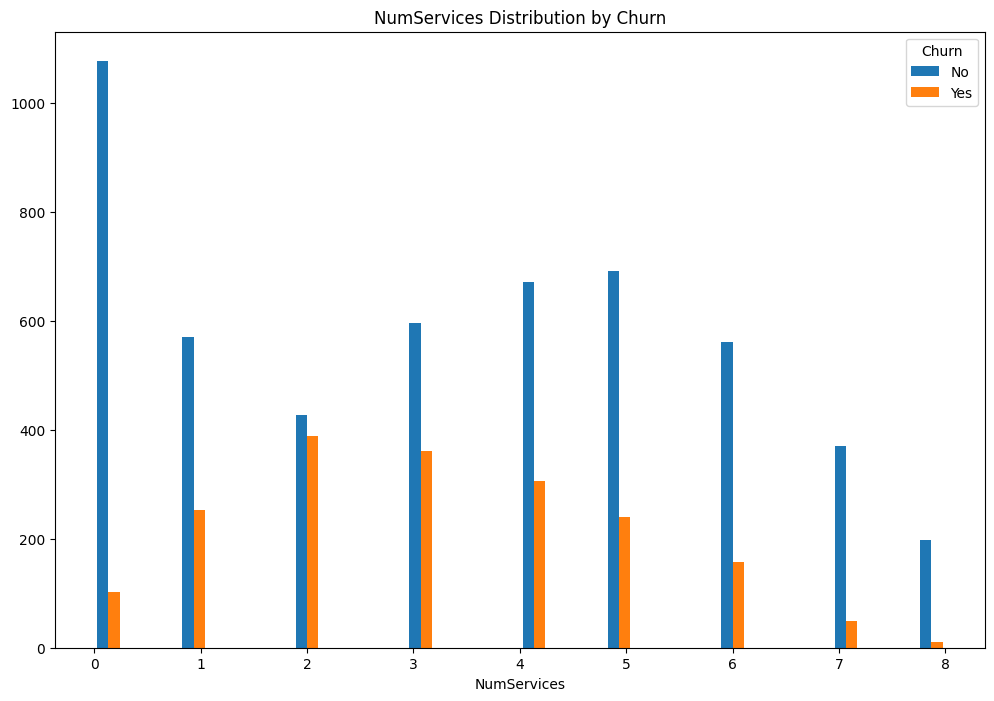

In [24]:
plot_numeric_vs_churn(df, 'NumServices')

In [25]:
df['TenureGroup'] = df['TenureGroup'].astype('object')

2.9745813790527432e-189


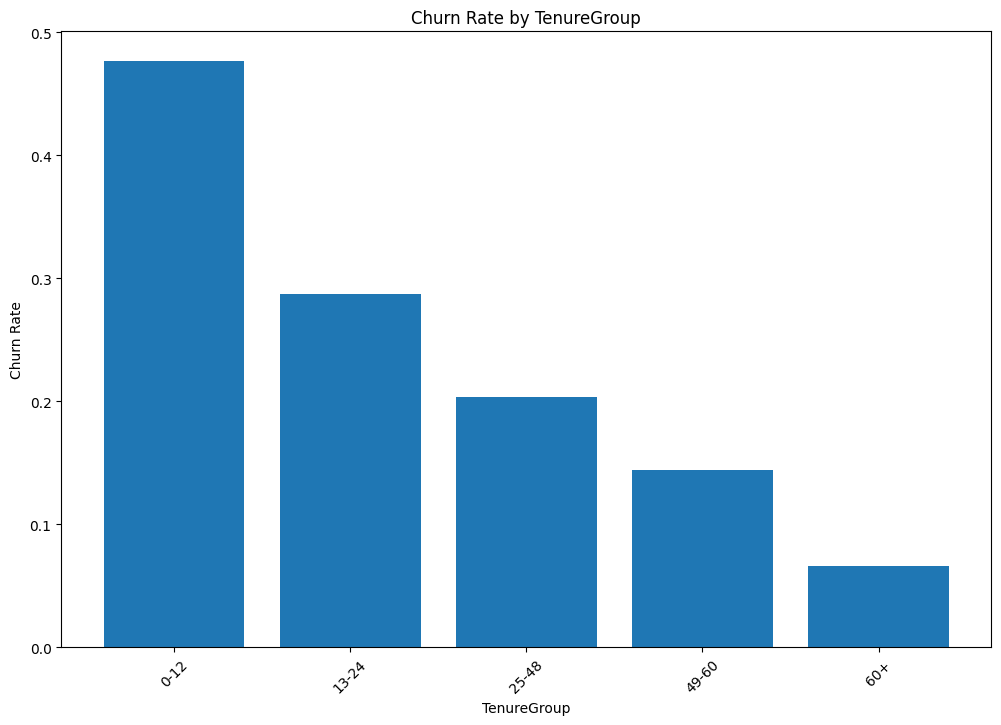

In [28]:
results = chi_square_tests(df)
print(results['TenureGroup'])
plot_categorical_vs_churn(df, 'TenureGroup')

In [38]:
from google.colab import files

uploaded = files.upload()


Saving precleaned-Telco-Customer-Churn.csv to precleaned-Telco-Customer-Churn (2).csv


In [49]:
import pandas as pd
df = pd.read_csv('precleaned-Telco-Customer-Churn.csv')

In [50]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
import pandas as pd
from sklearn import preprocessing

def encode_features(df):
    le = preprocessing.LabelEncoder()
    df['Churn'] = le.fit_transform(df['Churn'])

    oe = preprocessing.OrdinalEncoder(categories=[['No', 'Yes']] * 4)
    encoded_binary = oe.fit_transform(df[['Partner', 'Dependents', 'PaperlessBilling', 'SeniorCitizen']])

    df[['Partner', 'Dependents', 'PaperlessBilling', 'SeniorCitizen']] = encoded_binary

    df[['Partner', 'Dependents', 'PaperlessBilling', 'SeniorCitizen']] = df[
        ['Partner', 'Dependents', 'PaperlessBilling', 'SeniorCitizen']].astype(int)

    df = pd.get_dummies(df, columns=['Contract', 'PaymentMethod'], drop_first=True, dtype= int)

    oe_tenure = preprocessing.OrdinalEncoder()
    df['TenureGroup'] = oe_tenure.fit_transform(df[['TenureGroup']])
    df['TenureGroup'] = df['TenureGroup'].astype(int)

    return df, le, oe, oe_tenure



In [8]:
df['Churn'].dtype

dtype('O')

In [9]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit_transform(df['Churn'])

array([0, 0, 1, ..., 0, 1, 0])

In [10]:
print(le.classes_)


['No' 'Yes']


In [11]:
oe = preprocessing.OrdinalEncoder(categories=[['No', 'Yes']] * 4)
encoded_binary = oe.fit_transform(df[['Partner', 'Dependents', 'PaperlessBilling', 'SeniorCitizen']])

In [14]:
print(encoded[:5])

NameError: name 'encoded' is not defined

In [22]:
df[['Partner', 'Dependents', 'PaperlessBilling', 'SeniorCitizen']] = encoded_binary

In [23]:
print(df[['Partner', 'Dependents', 'PaperlessBilling', 'SeniorCitizen']].head())

   Partner  Dependents  PaperlessBilling  SeniorCitizen
0      1.0         0.0               1.0            0.0
1      0.0         0.0               0.0            0.0
2      0.0         0.0               1.0            0.0
3      0.0         0.0               0.0            0.0
4      0.0         0.0               1.0            0.0


In [27]:
df = pd.get_dummies(df, columns=['Contract', 'PaymentMethod'], drop_first=True)

In [34]:
oe_tenure = preprocessing.OrdinalEncoder()
df['TenureGroup'] = oe_tenure.fit_transform(df[['TenureGroup']])

In [35]:
df['TenureGroup']

,TenureGroup
0,0.0
1,2.0
2,0.0
3,2.0
4,0.0
...,...
7027,1.0
7028,4.0
7029,0.0
7030,0.0


In [55]:
df = pd.read_csv('precleaned-Telco-Customer-Churn.csv')
df.drop(columns=['gender', 'PhoneService'], inplace=True)
df = create_features(df)
df_enc, churn_le, binary_oe, tenure_oe = encode_features(df)

pd.set_option('display.max_columns', None)
print(df_enc.head())


   SeniorCitizen  Partner  Dependents  PaperlessBilling  MonthlyCharges  \
0              0        1           0                 1           29.85   
1              0        0           0                 0           56.95   
2              0        0           0                 1           53.85   
3              0        0           0                 0           42.30   
4              0        0           0                 1           70.70   

   TotalCharges  Churn  NumServices  TenureGroup  Contract_One year  \
0         29.85      0            2            0                  0   
1       1889.50      0            3            2                  1   
2        108.15      1            3            0                  0   
3       1840.75      0            4            2                  1   
4        151.65      1            1            0                  0   

   Contract_Two year  PaymentMethod_Credit card (automatic)  \
0                  0                                      0

In [56]:

df = pd.read_csv('precleaned-Telco-Customer-Churn.csv')
df.drop(columns=['gender', 'PhoneService'], inplace=True)
df = create_features(df)
df_enc, churn_le, binary_oe, tenure_oe = encode_features(df)

print(df_enc.dtypes)


SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
NumServices                                int64
TenureGroup                                int64
Contract_One year                          int64
Contract_Two year                          int64
PaymentMethod_Credit card (automatic)      int64
PaymentMethod_Electronic check             int64
PaymentMethod_Mailed check                 int64
dtype: object


In [57]:
def scale_numeric(df):
    scaler = preprocessing.StandardScaler()
    # numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    numeric_cols = ['MonthlyCharges', 'TotalCharges']
    scaler_numeric = scaler.fit_transform(df[numeric_cols])
    df[numeric_cols] = scaler_numeric

    return df

In [58]:
df = pd.read_csv('precleaned-Telco-Customer-Churn.csv')
df.drop(columns=['gender', 'PhoneService'], inplace=True)
df = create_features(df)
df_enc, _, _, _ = encode_features(df)
df_scaled = scale_numeric(df_enc)
print(df_scaled[['MonthlyCharges','TotalCharges']].describe().loc[['mean','std']])

      MonthlyCharges  TotalCharges
mean    6.062651e-17 -1.119064e-16
std     1.000071e+00  1.000071e+00


In [61]:
from sklearn import model_selection

def split_data(df, target='Churn', test_size=0.2, random_state=42):
    X = df.drop(target, axis=1)
    y = df[target]

    X_train, X_test, y_train, y_test = model_selection.train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

In [62]:


df = pd.read_csv('precleaned-Telco-Customer-Churn.csv')
df.drop(columns=['gender', 'PhoneService'], inplace=True)
df = create_features(df)
df_enc, _, _, _ = encode_features(df)
df_scaled = scale_numeric(df_enc)
X_train, X_test, y_train, y_test = split_data(df_scaled)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train Churn %:", y_train.mean(), "Test Churn %:", y_test.mean())

Train: (5625, 13) Test: (1407, 13)
Train Churn %: 0.2657777777777778 Test Churn %: 0.2658137882018479
